In [ ]:
Lab 2: Building an Analytical Base Table for Machine Learning


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)



In [13]:
DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = Path("../figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for file in DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [14]:
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

In [15]:
tables = {
    "orders": orders,
    "customers": customers,
    "reviews": reviews,
    "payments": payments,
    "order_items": order_items,
    "products": products,
    "category_translation": category_translation
}

for name, df in tables.items():
    print(name, df.shape)

orders (99441, 8)
customers (99441, 5)
reviews (99224, 7)
payments (103886, 5)
order_items (112650, 7)
products (32951, 9)
category_translation (71, 2)


In [16]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [17]:
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_day"] = orders["order_purchase_timestamp"].dt.day
orders["order_day_of_week"] = orders["order_purchase_timestamp"].dt.dayofweek
orders["order_hour"] = orders["order_purchase_timestamp"].dt.hour

orders[
    [
        "order_purchase_timestamp",
        "order_year",
        "order_month",
        "order_day",
        "order_day_of_week",
        "order_hour"
    ]
].head()

,order_purchase_timestamp,order_year,order_month,order_day,order_day_of_week,order_hour
0,2017-10-02 10:56:33,2017,10,2,0,10
1,2018-07-24 20:41:37,2018,7,24,1,20
2,2018-08-08 08:38:49,2018,8,8,2,8
3,2017-11-18 19:28:06,2017,11,18,5,19
4,2018-02-13 21:18:39,2018,2,13,1,21


In [18]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

orders["is_late_delivery"] = np.where(
    orders["delivery_delay_days"] > 0, 1, 0
)

orders[
    [
        "order_id",
        "delivery_days",
        "estimated_delivery_days",
        "delivery_delay_days",
        "is_late_delivery"
    ]
].head()

,order_id,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,-9.238171,0


In [19]:
orders["is_late_delivery"].value_counts()

is_late_delivery
0    91614
1     7827
Name: count, dtype: int64

In [20]:
orders["is_late_delivery"].value_counts(normalize=True) * 100

is_late_delivery
0    92.129001
1     7.870999
Name: proportion, dtype: float64

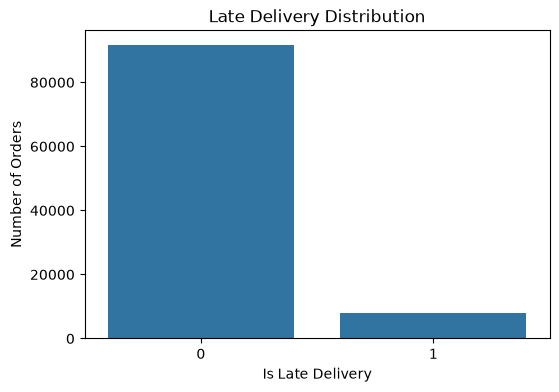

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(x="is_late_delivery", data=orders)

plt.title("Late Delivery Distribution")
plt.xlabel("Is Late Delivery")
plt.ylabel("Number of Orders")
plt.show()


In [22]:
payment_features = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    max_payment_installments=("payment_installments", "max"),
    payment_types_count=("payment_type", "nunique")
).reset_index()

payment_features.head()

,order_id,total_payment_value,max_payment_installments,payment_types_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [23]:
dominant_payment_type = payments.groupby("order_id")["payment_type"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

dominant_payment_type = dominant_payment_type.rename(
    columns={"payment_type": "dominant_payment_type"}
)

payment_features = payment_features.merge(
    dominant_payment_type,
    on="order_id",
    how="left"
)

payment_features.head()

,order_id,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [24]:
dominant_payment_type = payments.groupby("order_id")["payment_type"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

dominant_payment_type = dominant_payment_type.rename(
    columns={"payment_type": "dominant_payment_type"}
)

payment_features = payment_features.merge(
    dominant_payment_type,
    on="order_id",
    how="left"
)

payment_features.head()

,order_id,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type_x,dominant_payment_type_y
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card,credit_card


In [25]:
item_features = order_items.groupby("order_id").agg(
    total_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    unique_products=("product_id", "nunique"),
    unique_sellers=("seller_id", "nunique")
).reset_index()

item_features.head()

,order_id,total_items,total_price,total_freight,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [26]:
items_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [27]:
items_products = items_products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

items_products[
    [
        "order_id",
        "product_id",
        "product_category_name",
        "product_category_name_english"
    ]
].head()

,order_id,product_id,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools


In [28]:
order_category = items_products.groupby("order_id").agg(
    main_product_category=(
        "product_category_name_english",
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
).reset_index()

order_category.head()

,order_id,main_product_category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [29]:
review_features = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_comment_count=(
        "review_comment_message",
        lambda x: x.notnull().sum()
    ),
    has_review_comment=(
        "review_comment_message",
        lambda x: int(x.notnull().any())
    )
).reset_index()

review_features.head()

,order_id,review_score,review_comment_count,has_review_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,0,0
2,000229ec398224ef6ca0657da4fc703e,5.0,1,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1,1


In [30]:
abt = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [31]:
abt = abt.merge(
    review_features,
    on="order_id",
    how="left"
)

In [32]:
abt = abt.merge(
    payment_features,
    on="order_id",
    how="left"
)

In [33]:
abt = abt.merge(
    item_features,
    on="order_id",
    how="left"
)

In [34]:
abt = abt.merge(
    order_category,
    on="order_id",
    how="left"
)

In [35]:
abt.shape

(99441, 35)

In [36]:
abt.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type_x,dominant_payment_type_y,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,0,10,8.436574,15.544063,-7.107488,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0,1.0,1.0,38.71,1.0,2.0,voucher,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,1,20,13.782037,19.137766,-5.355729,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0,1.0,1.0,141.46,1.0,1.0,boleto,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,2,8,9.394213,26.639711,-17.245498,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0,0.0,0.0,179.12,3.0,1.0,credit_card,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,5,19,13.208750,26.188819,-12.980069,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0,1.0,1.0,72.20,1.0,1.0,credit_card,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,1,21,2.873877,12.112049,-9.238171,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0,0.0,0.0,28.62,1.0,1.0,credit_card,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [37]:
abt.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   order_year                     99441 non-null  int32         
 9   order_month                    99441 non-null  int32         
 10  order_day                      99441 non-null  int32         
 11  order_day_of_week         

In [38]:
abt["is_low_review"] = np.where(
    abt["review_score"] <= 2,
    1,
    0
)

In [39]:
abt["is_low_review"].value_counts()

is_low_review
0    84992
1    14449
Name: count, dtype: int64

In [40]:
final_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"
]

abt = abt[final_columns]

abt.head()

KeyError: "['dominant_payment_type'] not in index"

In [41]:
final_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"
]

abt = abt[final_columns]

abt.head()


KeyError: "['dominant_payment_type'] not in index"

In [42]:
dominant_payment_type = payments.groupby("order_id")["payment_type"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

dominant_payment_type = dominant_payment_type.rename(
    columns={"payment_type": "dominant_payment_type"}
)

payment_features = payment_features.merge(
    dominant_payment_type,
    on="order_id",
    how="left"
)

payment_features.head()

,order_id,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type_x,dominant_payment_type_y,dominant_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card,credit_card,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card,credit_card,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card,credit_card,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card,credit_card,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card,credit_card,credit_card


In [43]:
abt = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

abt = abt.merge(
    review_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    payment_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    item_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    order_category,
    on="order_id",
    how="left"
)

abt.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type_x,dominant_payment_type_y,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,0,10,8.436574,15.544063,-7.107488,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0,1.0,1.0,38.71,1.0,2.0,voucher,voucher,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,1,20,13.782037,19.137766,-5.355729,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0,1.0,1.0,141.46,1.0,1.0,boleto,boleto,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,2,8,9.394213,26.639711,-17.245498,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0,0.0,0.0,179.12,3.0,1.0,credit_card,credit_card,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,5,19,13.208750,26.188819,-12.980069,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0,1.0,1.0,72.20,1.0,1.0,credit_card,credit_card,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,1,21,2.873877,12.112049,-9.238171,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0,0.0,0.0,28.62,1.0,1.0,credit_card,credit_card,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [44]:
abt.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_year',
 'order_month',
 'order_day',
 'order_day_of_week',
 'order_hour',
 'delivery_days',
 'estimated_delivery_days',
 'delivery_delay_days',
 'is_late_delivery',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_score',
 'review_comment_count',
 'has_review_comment',
 'total_payment_value',
 'max_payment_installments',
 'payment_types_count',
 'dominant_payment_type_x',
 'dominant_payment_type_y',
 'dominant_payment_type',
 'total_items',
 'total_price',
 'total_freight',
 'unique_products',
 'unique_sellers',
 'main_product_category']

In [45]:
final_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"
]

abt = abt[final_columns]

abt.head()

KeyError: "['is_low_review'] not in index"

In [46]:
abt = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

abt = abt.merge(
    review_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    payment_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    item_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    order_category,
    on="order_id",
    how="left"
)

In [47]:
abt["is_low_review"] = np.where(
    abt["review_score"] <= 2,
    1,
    0
)

abt["is_low_review"].value_counts()

is_low_review
0    84992
1    14449
Name: count, dtype: int64

In [48]:
print("review_score" in abt.columns)
print("is_low_review" in abt.columns)
print("dominant_payment_type" in abt.columns)

True
True
True


In [49]:
final_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"
]

abt = abt[final_columns]

abt.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.436574,15.544063,-7.107488,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.782037,19.137766,-5.355729,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.394213,26.639711,-17.245498,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.208750,26.188819,-12.980069,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.873877,12.112049,-9.238171,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [50]:
abt.isnull().sum().sort_values(ascending=False)

delivery_days               2965
delivery_delay_days         2965
main_product_category       2185
total_freight                775
unique_sellers               775
unique_products              775
total_price                  775
total_items                  775
review_score                 768
has_review_comment           768
review_comment_count         768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
order_day_of_week              0
order_day                      0
estimated_delivery_days        0
order_hour                     0
order_status                   0
customer_state                 0
order_id                       0
customer_city                  0
customer_unique_id             0
customer_id                    0
order_year                     0
order_month                    0
is_late_delivery               0
is_low_review                  0
dtype: int64

In [51]:
abt.isnull().sum().sort_values(ascending=False).head(10)

delivery_days            2965
delivery_delay_days      2965
main_product_category    2185
total_freight             775
unique_sellers            775
unique_products           775
total_price               775
total_items               775
review_score              768
has_review_comment        768
dtype: int64

In [52]:
abt["order_id"].duplicated().sum()

np.int64(0)

In [53]:
abt_summary = pd.DataFrame({
    "column": abt.columns,
    "data_type": abt.dtypes.astype(str).values,
    "missing_count": abt.isnull().sum().values,
    "missing_percent": (
        abt.isnull().sum().values / len(abt)
    ) * 100,
    "unique_values": [
        abt[col].nunique() for col in abt.columns
    ]
})

abt_summary.head()

,column,data_type,missing_count,missing_percent,unique_values
0,order_id,str,0,0.0,99441
1,customer_id,str,0,0.0,99441
2,customer_unique_id,str,0,0.0,96096
3,customer_city,str,0,0.0,4119
4,customer_state,str,0,0.0,27


In [54]:
abt_summary.to_csv(
    REPORTS_DIR / "lab02_abt_summary.csv",
    index=False
)

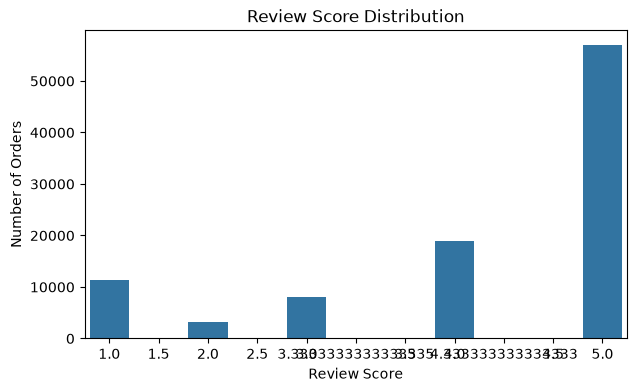

In [55]:
plt.figure(figsize=(7, 4))

sns.countplot(
    x="review_score",
    data=abt
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.show()

In [56]:
plt.savefig(
    FIGURES_DIR / "review_score_distribution.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

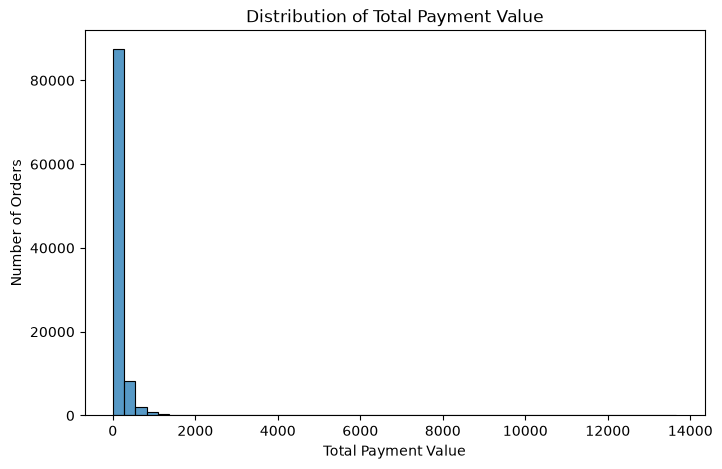

In [57]:
plt.figure(figsize=(8, 5))

sns.histplot(
    abt["total_payment_value"],
    bins=50
)

plt.title("Distribution of Total Payment Value")
plt.xlabel("Total Payment Value")
plt.ylabel("Number of Orders")
plt.show()

In [58]:
plt.savefig(
    FIGURES_DIR / "payment_value_distribution.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

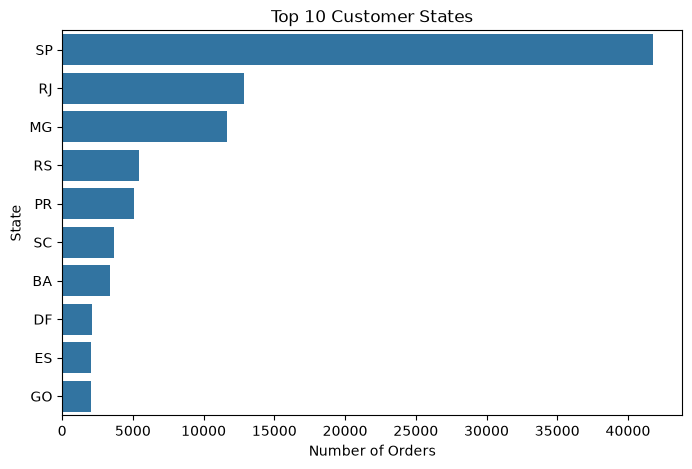

In [59]:
top_states = abt["customer_state"].value_counts().head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 Customer States")
plt.xlabel("Number of Orders")
plt.ylabel("State")
plt.show()

In [60]:
plt.savefig(
    FIGURES_DIR / "top_customer_states.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [61]:
abt.to_csv(
    PROCESSED_DIR / "olist_orders_abt.csv",
    index=False
)

In [62]:
(PROCESSED_DIR / "olist_orders_abt.csv").exists()

True

In [63]:
abt_check = pd.read_csv(
    PROCESSED_DIR / "olist_orders_abt.csv"
)

abt_check.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.436574,15.544063,-7.107488,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.782037,19.137766,-5.355729,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.394213,26.639711,-17.245498,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.208750,26.188819,-12.980069,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.873877,12.112049,-9.238171,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [64]:
abt_check.shape

(99441, 29)

. What is an Analytical Base Table?

An Analytical Base Table (ABT) is a single structured dataset prepared for machine learning, where each row represents one analytical entity, in this case one order, and columns contain features and target variables.

2. Why should the ABT have one row per order?

Because the main unit of analysis is the order. Having one row per order prevents duplicate orders and makes the dataset suitable for machine learning.

3. Why do we aggregate payments and order items?

Payments and order items can have multiple records for the same order. Aggregating them creates order-level features without creating duplicate order rows.

4. What happens if we directly merge one-to-many tables?

A direct merge can create multiple rows for the same order, causing duplicate records and incorrect feature values.

5. Which feature could help predict late delivery?

delivery_days, estimated_delivery_days, customer_state, and order-related features could help predict late delivery.

6. Which feature could help predict low review?

Delivery-related features such as delivery_delay_days, is_late_delivery, and payment/order features could help predict low review scores.

7. Difference between review_score and is_low_review?

review_score is the original numerical review rating from 1 to 5. is_low_review converts it into a binary target where 1 means the review score is 2 or below.

8. Why is is_late_delivery a classification target?

Because it contains two categories: 0 for not late and 1 for late.

9. Which columns should not be used directly as ML features?

Identifiers such as order_id, customer_id, and customer_unique_id generally should not be used directly as predictive features because they identify records rather than represent meaningful behavioral characteristics.

The Analytical Base Table converts the raw Olist relational data into a machine-learning-ready dataset. Multiple tables such as orders, customers, payments, order items, products, and reviews are combined after aggregating one-to-many relationships. New features such as delivery time, delivery delay, payment information, item counts, and product category are created. Target variables such as is_late_delivery and is_low_review are also created. This ABT can be used in future experiments for machine learning model training and evaluation.

In [65]:
print("ABT shape:", abt.shape)
print("Duplicate orders:", abt["order_id"].duplicated().sum())
print("ABT saved:", (PROCESSED_DIR / "olist_orders_abt.csv").exists())
print("Summary saved:", (REPORTS_DIR / "lab02_abt_summary.csv").exists())

ABT shape: (99441, 29)
Duplicate orders: 0
ABT saved: True
Summary saved: True
